In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import importlib
import astropy.units as u
import pandas as pd

import sys
from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

import Plots
import Measurements
import Models.Studies as Studies
import Models.HaloModels as HaloModels

# Plot Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
})

# Ried-Guachalla 2025

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


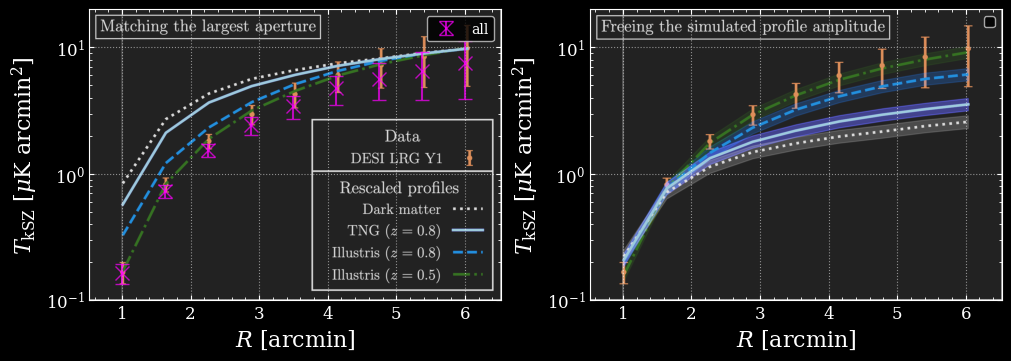

In [27]:
importlib.reload(Plots); importlib.reload(Measurements)
fig, axs = Plots.RiedGuachalla2025().Fig8()

RG25 = Measurements.RiedGuachalla2025({'bin':'all'})

axs[0].errorbar(RG25.R, RG25.kSZ_data, RG25.kSZ_err, markersize=10, capsize=5, marker='x', alpha=0.7, ls='', label=f'all', c='magenta')

for ax in axs: ax.legend()
plt.show()

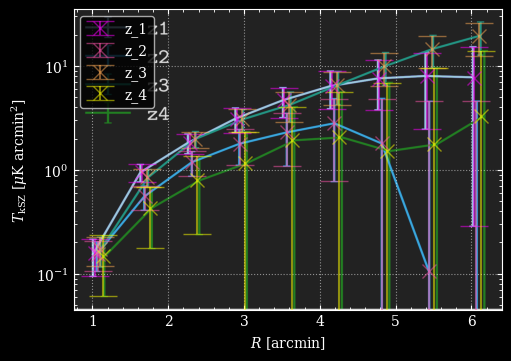

In [ ]:
importlib.reload(Plots); importlib.reload(Measurements)
fig, ax = Plots.RiedGuachalla2025().Fig11()

bins = ['z_1', 'z_2', 'z_3', 'z_4']
colors = [plt.colormaps['spring'](i) for i in np.linspace(0, 1, len(bins))]
for i, bin in enumerate(bins):
    RG25 = Measurements.RiedGuachalla2025({'bin':bin})
    ax.errorbar(RG25.R+np.int32(bin[-1])/30*u.arcmin, RG25.kSZ_data, RG25.kSZ_err, alpha=0.5, marker='x', c=colors[i], markersize=10, capsize=10, ls='', label=f'{bin}')

ax.legend()
plt.show()

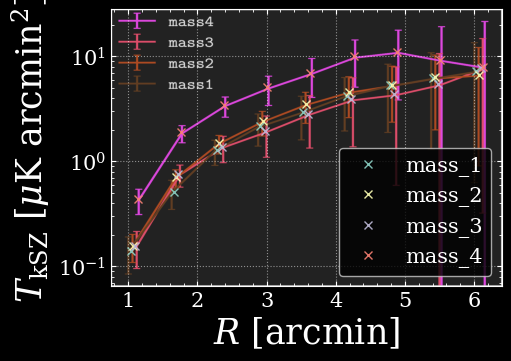

In [5]:
importlib.reload(Plots); importlib.reload(Measurements)
fig, ax = Plots.RiedGuachalla2025().Fig12()

for bin in ['mass_1', 'mass_2', 'mass_3', 'mass_4']:
    RG25 = Measurements.RiedGuachalla2025({'bin':bin})
    ax.errorbar(RG25.R+np.int32(bin[-1])/30*u.arcmin, RG25.TkSZ_data, RG25.TkSZ_err, lw=0,alpha=0.9,marker='x', label=f'{bin}')

ax.legend()
plt.show()

# Liu 2025

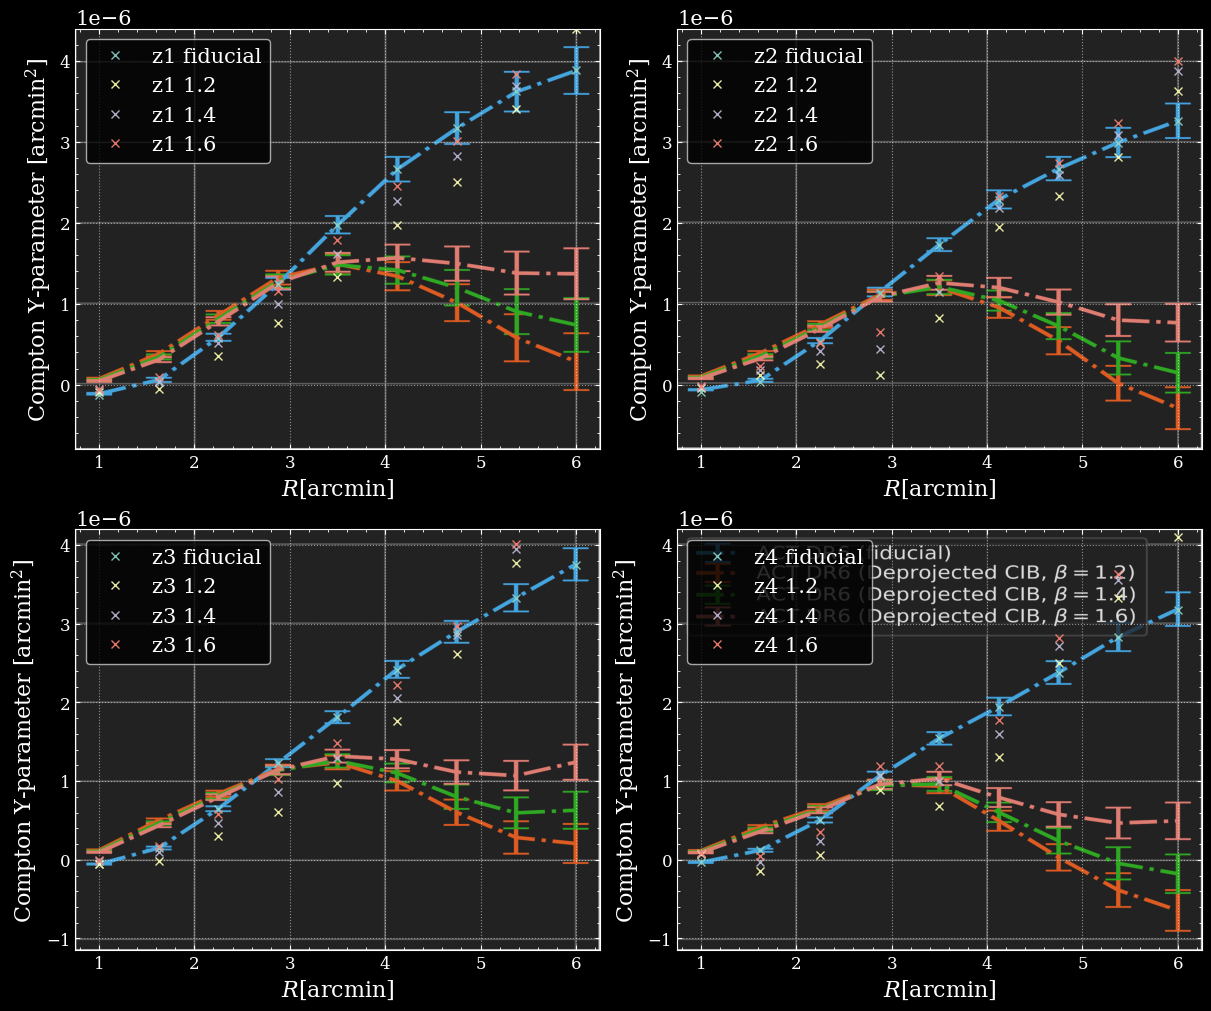

In [ ]:
importlib.reload(Plots); importlib.reload(Measurements)
fig, axs = Plots.Liu2025().Fig3()

for zbin, ax in zip(['z1', 'z2', 'z3', 'z4'], axs.flatten()):
    for beta in Measurements.Liu2025.subs['Beta']:
        L25 = Measurements.Liu2025({'zbin':zbin, 'Beta':beta, 'ACTDR':'DR6', 'dp':'beta', 'TCIB':'10.7'})
        ax.errorbar(L25.R, L25.y_data, L25.y_err, lw=0,alpha=0.9,marker='x', label=f'{zbin} {beta}')
    ax.legend()
plt.show()

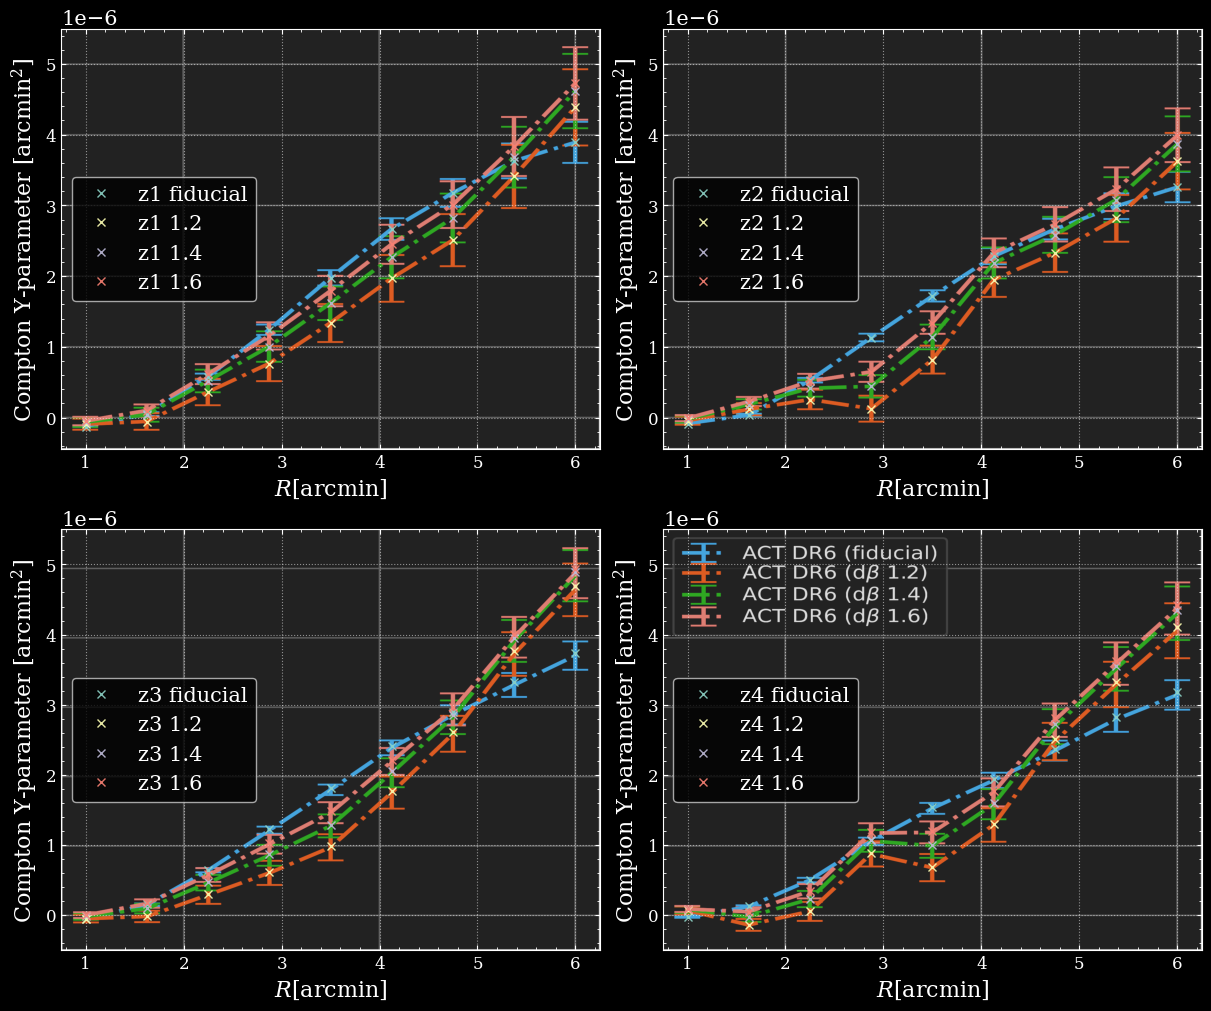

In [81]:
importlib.reload(Plots); importlib.reload(Measurements)
fig, axs = Plots.Liu2025().Fig4()

for zbin, ax in zip(['z1', 'z2', 'z3', 'z4'], axs.flatten()):
    for beta in Measurements.Liu2025.subs['Beta']:
        L25 = Measurements.Liu2025({'zbin':zbin, 'Beta':beta, 'ACTDR':'DR6', 'dp':'dBeta', 'TCIB':'10.7'})
        ax.errorbar(L25.R, L25.y_data, L25.y_err, lw=0,alpha=0.9,marker='x', label=f'{zbin} {beta}')
    ax.legend(loc='center left')
plt.show()

# Moore 2026

NameError: bin L36 doesn't exist, choose from: ['L35', 'L47', 'L59', 'L78', 'L98', 'L35D', 'L47D', 'L59D', 'L78D', '10.0', '10.25', '10.5', '10.75', '11.0', '11.25', 'all', '10', '20']

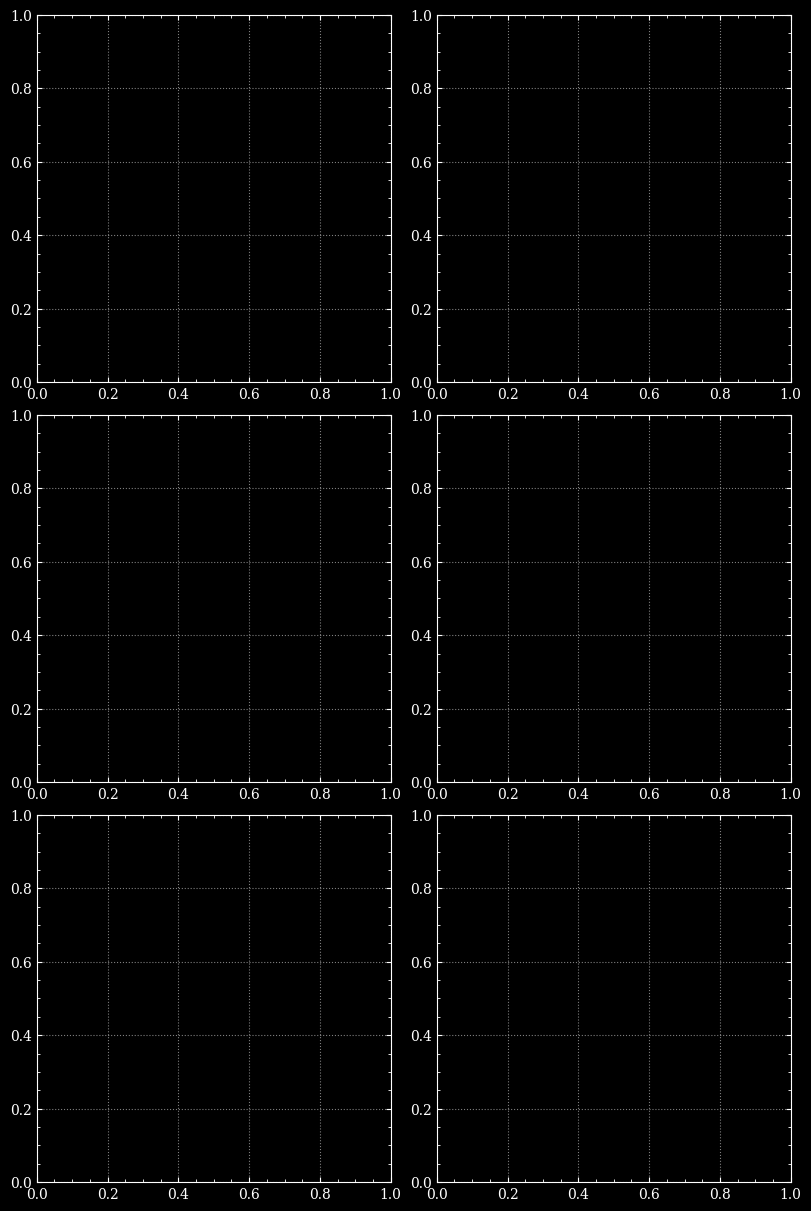

In [2]:
importlib.reload(Plots); importlib.reload(Measurements)
fig, axs = plt.subplots(3, 2, figsize=(8, 12), layout='constrained')

for prof, ax in zip(['f090_raw', 'f150_raw', 'f090_corrected', 'f150_corrected', 'f220_raw'], axs.flatten()):
    for lbin in ['L36', 'L48', 'L60', 'L79', 'L98', 'L36D', 'L48D', 'L60D', 'L79D']:
        L25 = Measurements.Moore2026({'sample':'lrg', 'prof':prof, 'bin':lbin })
        ax.errorbar(L25.R, L25.tSZ_data, L25.tSZ_err,alpha=0.9,marker='x', label=lbin)
    ax.legend(loc='lower left')
plt.show()

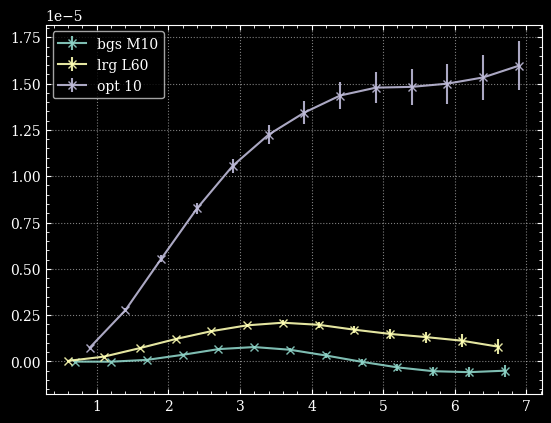

In [12]:
importlib.reload(Plots); importlib.reload(Measurements)

L25 = Measurements.Moore2026({'sample':'bgs', 'prof':'ilc_cib_deproj', 'bin':'10.0', 'radio':'2p7'})
plt.errorbar(L25.R, L25.tSZ_data, L25.tSZ_err,alpha=0.9,marker='x', label='bgs M10')

L25 = Measurements.Moore2026({'sample':'lrg', 'prof':'ilc_cib_deproj', 'bin':'L60', 'radio':'2p1'})
plt.errorbar(L25.R, L25.tSZ_data, L25.tSZ_err,alpha=0.9,marker='x', label='lrg L60')

L25 = Measurements.Moore2026({'sample':'opt', 'prof':'ilc_cib_deproj', 'bin':'10', 'radio':'2p4'})
plt.errorbar(L25.R, L25.tSZ_data, L25.tSZ_err,alpha=0.9,marker='x',label='opt 10')

plt.legend()

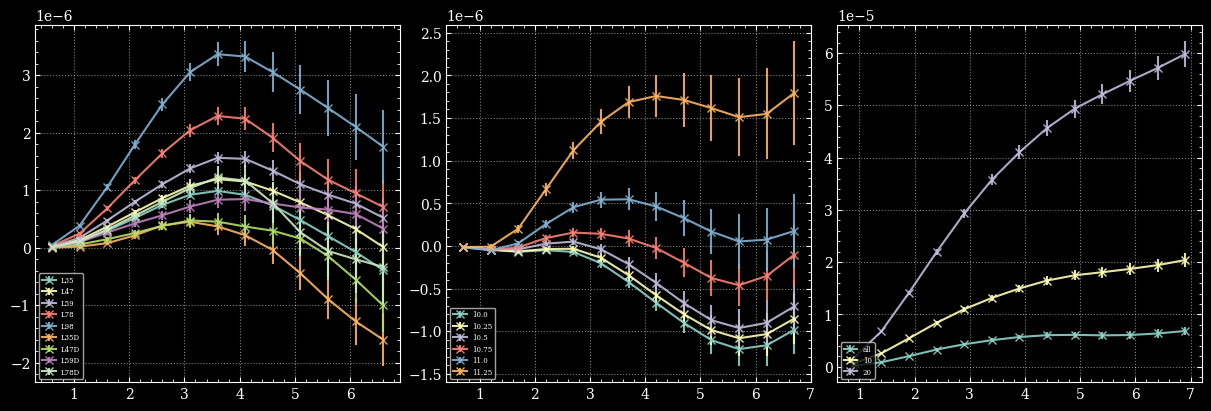

In [3]:
importlib.reload(Plots); importlib.reload(Measurements)
fig, axs = plt.subplots(1, 3, figsize=(12, 4), layout='constrained')

for sample, ax in zip(['lrg', 'bgs', 'opt'], axs.flatten()):
    if sample=='bgs':
        binlist = ['10.0', '10.25', '10.5', '10.75', '11.0', '11.25']
    elif sample=='opt':
        binlist = ['all', '10', '20']
    else:
        binlist = ['L35', 'L47', 'L59', 'L78', 'L98', 'L35D', 'L47D', 'L59D', 'L78D']
    for bin in binlist:
        L25 = Measurements.Moore2026({'sample':sample, 'prof':'ilc_CIB_deproj', 'bin':bin})
        ax.errorbar(L25.R, L25.tSZ_data, L25.tSZ_err,alpha=0.9,marker='x', label=bin)
    ax.legend(loc='lower left', fontsize=5)
plt.show()

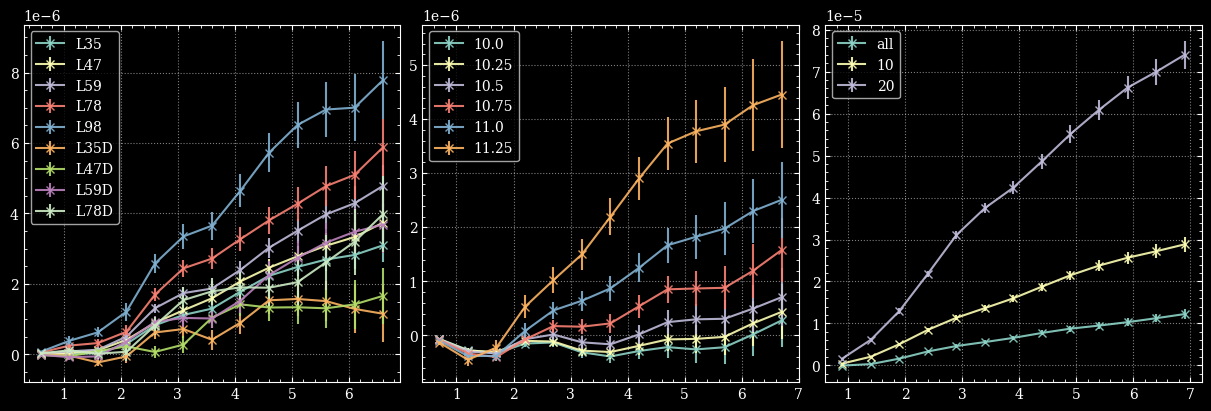

In [7]:
importlib.reload(Plots); importlib.reload(Measurements)
fig, axs = plt.subplots(1, 3, figsize=(12, 4), layout='constrained')

for sample, ax in zip(['lrg', 'bgs', 'opt'], axs.flatten()):
    if sample=='bgs':
        binlist = ['10.0', '10.25', '10.5', '10.75', '11.0', '11.25']
    elif sample=='opt':
        binlist = ['all', '10', '20']
    else:
        binlist = ['L35', 'L47', 'L59', 'L78', 'L98', 'L35D', 'L47D', 'L59D', 'L78D']
    for bin in binlist:
        M26 = Measurements.Moore2026({'sample':sample, 'prof':'ilc_dB_deproj', 'bin':bin})
        ax.errorbar(M26.R, M26.tSZ_data, M26.tSZ_err,alpha=0.9,marker='x', label=bin)
    ax.legend(loc='upper left', fontsize=10)
plt.show()

In [8]:
# importlib.reload(Plots); importlib.reload(Studies); importlib.reload(Measurements)

# fig, axs = plt.subplots(2, 2, figsize=(8, 6), layout='constrained')

# for ax, dp in zip(axs.flatten(), ['_f090', '_f150', '_ILC']):
#     lbins = Measurements.Moore2026.subs['Lbin']
#     for i, Lbin in enumerate(lbins):
#         M26 = Measurements.Moore2026(sample='LRG_raw', deproj=dp, Lbin=Lbin)
#         ax.errorbar(M26.R+i/100*u.arcmin, M26.tSZ_data*np.pi*M26.R**2, M26.tSZ_err*np.pi*M26.R**2, capsize=10, marker='o', alpha=0.7, color=plt.colormaps['spring'](i*50), label=Lbin)
#     ax.legend(title=dp, fontsize=5)
#     ax.set_xlabel(r'$R$ [arcmin]')
#     ax.set_ylabel(r'$T_\text{tSZ}$ [$\mu$ K arcmin$^2$]')

# plt.show()

In [9]:
# importlib.reload(Plots); importlib.reload(Studies); importlib.reload(Measurements)

# fig, axs = plt.subplots(2, 2, figsize=(8, 6), layout='constrained')

# for ax, dp in zip(axs.flatten(), ['_f090', '_f150', '_ILC']):
#     lbins = Measurements.Moore2026.subs['Lbin']
#     for i, Lbin in enumerate(lbins):
#         M26 = Measurements.Moore2026(sample='LRG_raw', deproj=dp, Lbin=Lbin)
#         ax.errorbar(M26.R+i/100*u.arcmin, M26.tSZ_data*np.pi*M26.R**2, M26.tSZ_err*np.pi*M26.R**2, capsize=10, marker='o', alpha=0.7, color=plt.colormaps['spring'](i*50), label=Lbin)
#     ax.legend(title=dp, fontsize=5)
#     ax.set_xlabel(r'$R$ [arcmin]')
#     ax.set_ylabel(r'$T_\text{tSZ}$ [$\mu$ K arcmin$^2$]')

# plt.show()

# Schaan 2021

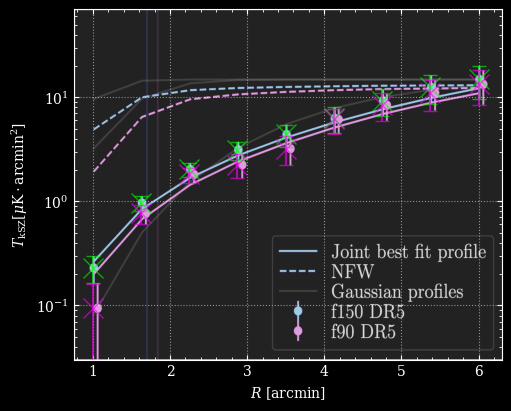

In [44]:
importlib.reload(Plots); importlib.reload(Measurements)
fig, ax = Plots.Schaan2021().Fig7a()

S21 = Measurements.Schaan2021(sample='cmass', freq='150')
ax.errorbar(S21.R, S21.kSZ_data, S21.kSZ_err, c='lime', marker='x', ls='', markersize=15, alpha=0.6, capsize=5)

S21 = Measurements.Schaan2021(sample='cmass', freq='090')
ax.errorbar(S21.R, S21.kSZ_data, S21.kSZ_err, c='magenta', marker='x', ls='', markersize=15, alpha=0.6, capsize=5)

plt.show()

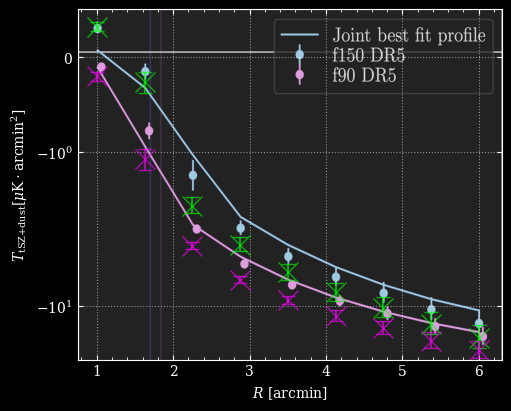

In [22]:
importlib.reload(Plots); importlib.reload(Measurements)
fig, ax = Plots.Schaan2021().Fig9()
ax.set_yscale('symlog', linthresh=1.5)
ax.set(ylim=(-26, 0.5))

S21 = Measurements.Schaan2021(sample='cmass', freq='150')
ax.errorbar(S21.R, S21.tSZ_data, S21.tSZ_err, c='lime', marker='x', ls='', markersize=15, alpha=0.6, capsize=5)

S21 = Measurements.Schaan2021(sample='cmass', freq='090')
ax.errorbar(S21.R, S21.tSZ_data, S21.tSZ_err, c='magenta', marker='x', ls='', markersize=15, alpha=0.6, capsize=5)

plt.show()

# Stacked

In [10]:
importlib.reload(Studies); importlib.reload(Measurements); HaloModels

Liu2025 = Measurements.Liu2025({'zbin':'z1', 'ACTDR':'DR6', 'dp':'dBeta', 'Beta':'1.2', 'TCIB':'10.7'})
Liu2025DR5 = Measurements.Liu2025({'zbin':'z1', 'ACTDR':'DR5', 'freq':'090', 'aper':'RingRing'})
Hadzhiyska2025 = Measurements.Hadzhiyska2025({'zbin':'z1','DR':'all', 'sample':'main', 'corr':'uncorrected', 'zoutcut':'nocut'})
Guachalla2025 = Measurements.RiedGuachalla2025({'bin':'z_1'})
Schaan2021 = Measurements.Schaan2021({'sample':'cmass', 'freq':'150'})

AttributeError: module 'Models.HaloModels' has no attribute 'y_to_uK'

NameError: name 'Schaan2021' is not defined

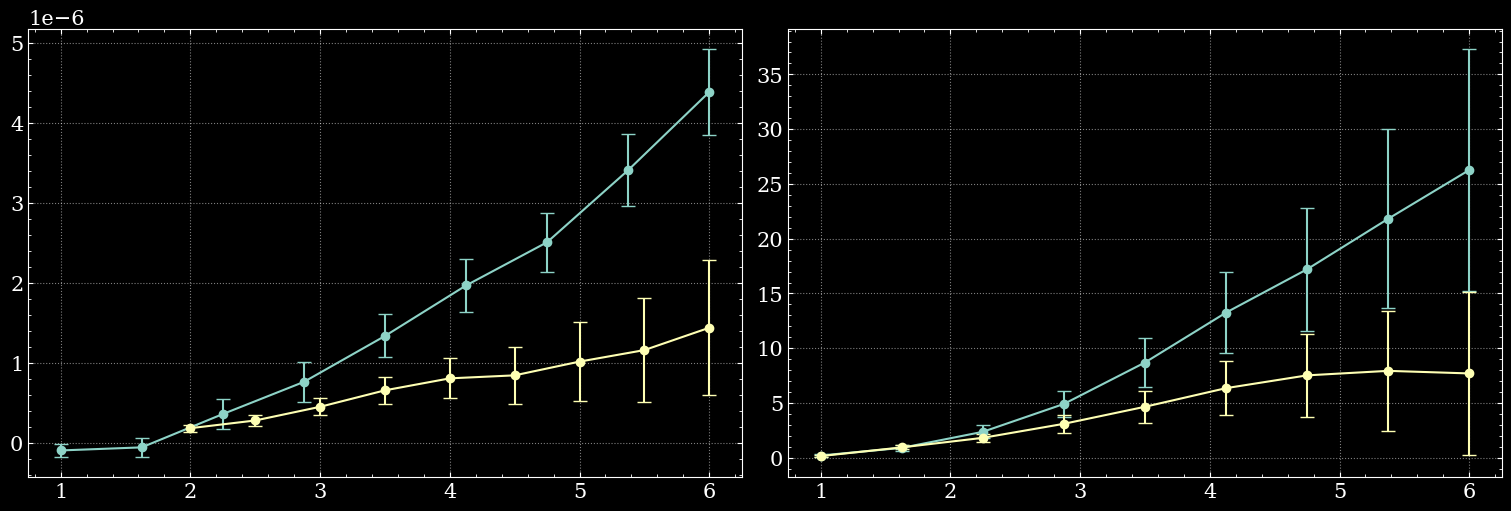

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout='constrained', sharex='col')

axs[0].errorbar(Liu2025.R, Liu2025.y_data, Liu2025.y_err, capsize=5, marker='o', label='Liu 2025')

axs[0].errorbar(Liu2025DR5.R, Liu2025DR5.y_data, Liu2025DR5.y_err, capsize=5, marker='o' ,label='Liu 2025, DR5')

axs[1].errorbar(Hadzhiyska2025.R, Hadzhiyska2025.TkSZ_data, Hadzhiyska2025.TkSZ_err, capsize=5, marker='o' ,label='Hadzhiyska 2025')

axs[1].errorbar(Guachalla2025.R, Guachalla2025.TkSZ_data, Guachalla2025.TkSZ_err, capsize=5, marker='o', label='Guachalla 2025')

axs[0].errorbar(Schaan2021.R, Schaan2021.y_data, Schaan2021.y_err, capsize=5, marker='o', label='Schaan 2021')
axs[1].errorbar(Schaan2021.R, Schaan2021.TkSZ_data, Schaan2021.TkSZ_err, capsize=5, marker='o', label='Schaan 2021')

axs[0].set(xlabel=r'$R \ [\text{arcmin}]$', ylabel=r'$y \ [\text{arcmin}^2$]'); axs[0].legend(title=r'$150$GHz')
axs[1].set(xlabel=r'$R \ [\text{arcmin}]$', ylabel=r'$T_\text{kSZ} \ [\mu\text{K} \text{arcmin}^2$]', yscale='log'); axs[1].legend(loc='lower right')
plt.show()

# Spectra

In [ ]:
import Models.Data as Data
importlib.reload(Data)

White2022 = Data.White2022({'zbin':'z1'})
Zhou2023 = Data.Zhou2023({'zbin':'z1', 'sample':'main', 'hemisphere':'combined'})
Koukoufilippas2020 = Data.Koukoufilippas2020({'sample':'WIxSC-5'})
Kou2023 = Data.Kou2023({'mbin':'M1'})
Kusiak2022 = Data.Kusiak2022({'sample':'Red'})
Popik2025 = Data.Popik2025({'zbin': 'z1', 'deproj':'cib_cibdBeta', 'TCIB':'10.7', 'beta':'1.2'})

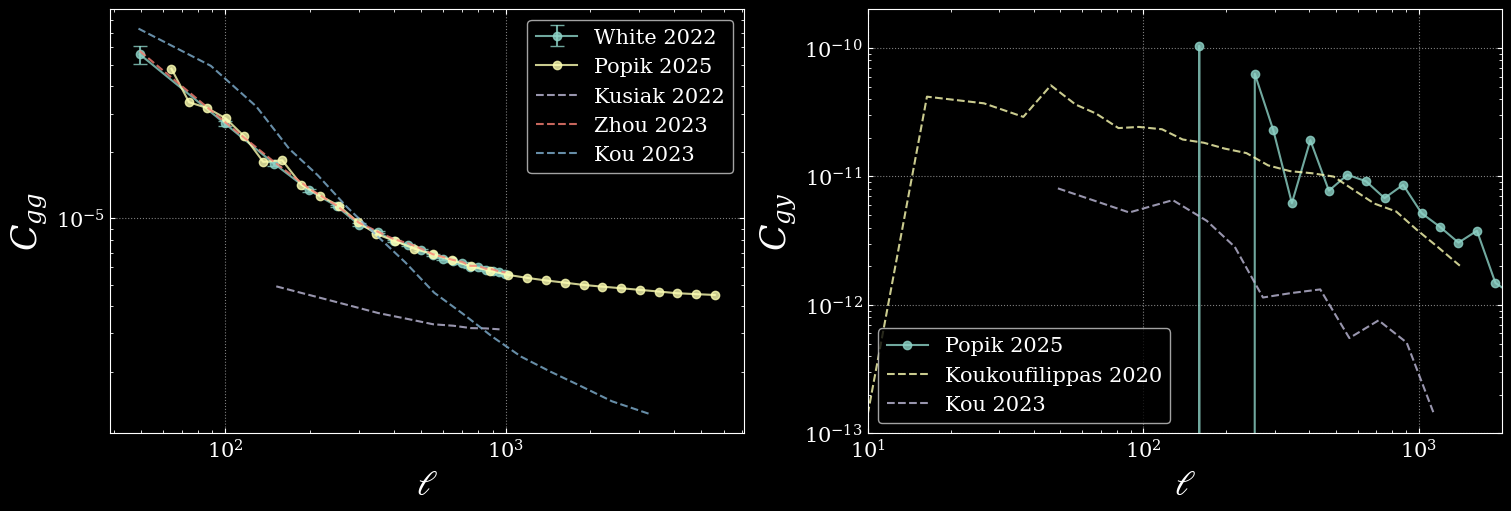

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout='constrained', sharex='col')

axs[0].errorbar(White2022.ell, White2022.Cgg_data, White2022.Cgg_err, marker='o', alpha=0.8, capsize=5,  label='White 2022')

axs[0].errorbar(Popik2025.ell, Popik2025.Cgg_data, alpha=0.8, marker='o', label='Popik 2025')
axs[1].errorbar(Popik2025.ell, Popik2025.Cgy_data, alpha=0.8, marker='o', label='Popik 2025')


# axs[0].plot(Koukoufilippas2020.Cgg_ell, Koukoufilippas2020.Cgg_data, marker='o', alpha=0.8, label='Koukoufilippas 2020')
axs[1].errorbar(Koukoufilippas2020.Cgy_ell, Koukoufilippas2020.Cgy_data, ls='--', alpha=0.8, label='Koukoufilippas 2020')

axs[0].errorbar(Kusiak2022.ell, Kusiak2022.Cgg_data, alpha=0.8, ls='--',label='Kusiak 2022')

axs[0].errorbar(Zhou2023.ell, Zhou2023.Cgg_data, alpha=0.8, ls='--', label='Zhou 2023')

axs[0].errorbar(Kou2023.Cgg_ell, Kou2023.Cgg_data, alpha=0.8, ls='--', label='Kou 2023')
axs[1].errorbar(Kou2023.Cgy_ell, Kou2023.Cgy_data, alpha=0.8, ls='--', label='Kou 2023')


axs[0].set(xlabel=r'$\ell$', ylabel=r'$C_{gg}$', xscale='log', yscale='log'); axs[0].legend()
axs[1].set(xlabel=r'$\ell$', ylabel=r'$C_{gy}$', xscale='log', yscale='log', xlim=(10, 2000), ylim=(1e-13, 2e-10)); axs[1].legend()
plt.show()

In [32]:
importlib.reload(Plots); importlib.reload(Measurements)

RG25 = Measurements.RiedGuachalla2025({'bin':bin})
np.diag(RG25.TkSZ_cov)**0.5

<Quantity [ 0.08647105,  0.25572033,  0.55352731,  1.17285991,  2.11286193,
            3.56735654,  5.37745038,  7.82161758, 10.57319881] arcmin2 uK>

# Hadzhiyska 2025

# Kou 2023

# Kusiak 2022

# White 2022

In [ ]:
import Models.Data as Data
importlib.reload(Data)

White2022 = Data.White2022({'zbin':'z1'})

fig, axs = plt.subplots(1, 1, figsize=(10, 5), layout='constrained', sharex='col')

axs[0].errorbar(White2022.ell, White2022.Cgg_data, White2022.Cgg_err, marker='o', alpha=0.8, capsize=5,  label='White 2022')



ax.set(xlabel=r'$\ell$', ylabel=r'$C_{gg}$', xscale='log', yscale='log'); axs[0].legend()
axs[1].set(xlabel=r'$\ell$', ylabel=r'$C_{gy}$', xscale='log', yscale='log', xlim=(10, 2000), ylim=(1e-13, 2e-10)); axs[1].legend()
plt.show()